# Fitting and machine learning

In Section 2 you fit a straight line to the planet data *by hand*. In this notebook we use
Python to fit several different **models** and measure how well each one fits, using the same
loss function as before: the **mean squared error (MSE)**.

Run the cells one by one, and answer the questions in the worksheet as you go.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The data

Orbital period $T$ (in years) and semi-major axis $a$ (in AU) for all eight planets of the solar system.

In [2]:
planets = pd.DataFrame({
    "planet":  ["Mercury","Venus","Earth","Mars","Jupiter","Saturn","Uranus","Neptune"],
    "T_years": [0.2408467, 0.61519726, 1.0000174, 1.8808158, 11.862615, 29.447498, 84.016846, 164.79132],
    "a_au":    [0.38709893, 0.72333199, 1.00000011, 1.52366231, 5.20336301, 9.53707032, 19.19126393, 30.06896348],
})
planets

,planet,T_years,a_au
0,Mercury,0.240847,0.387099
1,Venus,0.615197,0.723332
2,Earth,1.000017,1.000000
3,Mars,1.880816,1.523662
4,Jupiter,11.862615,5.203363
5,Saturn,29.447498,9.537070
6,Uranus,84.016846,19.191264
7,Neptune,164.791320,30.068963


## Plot the data

We put the period $T$ on the x-axis and the semi-major axis $a$ on the y-axis, because our goal
is to predict $a$ from $T$.

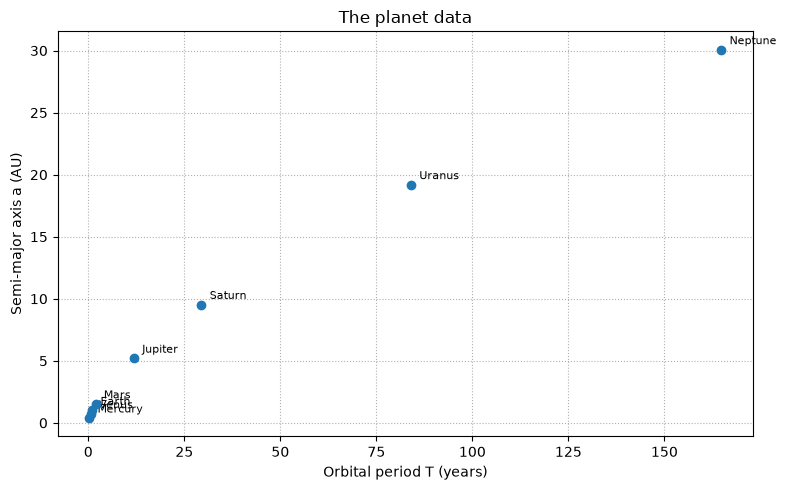

In [3]:
def plot_data(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(planets["T_years"], planets["a_au"], color="tab:blue", zorder=5)
    for _, row in planets.iterrows():
        ax.annotate(row["planet"], (row["T_years"], row["a_au"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel("Orbital period T (years)")
    ax.set_ylabel("Semi-major axis a (AU)")
    ax.grid(True, linestyle=":")
    return ax

plot_data()
plt.title("The planet data")
plt.tight_layout()
plt.show()

## 1. The linear model — checking your result from Section 2

In Section 2 you fit the model $a = c\,T$ through the **four inner planets** and found
$c \approx 0.885$ by hand. Let's reproduce that with Python.

For a line through the origin, the optimal slope is
$$ c = \frac{\sum_i T_i\,a_i}{\sum_i T_i^2}. $$

In [4]:
def mse(a_true, a_pred):
    return np.mean((a_true - a_pred) ** 2)

inner = planets.iloc[:4]   # Mercury..Mars  (training data)
outer = planets.iloc[4:]   # Jupiter..Neptune (testing data)

T_in, a_in = inner["T_years"].values, inner["a_au"].values
T_out, a_out = outer["T_years"].values, outer["a_au"].values

c = np.sum(T_in * a_in) / np.sum(T_in ** 2)

print(f"optimal slope c            = {c:.4f}")
print(f"MSE on inner 4 (training)  = {mse(a_in, c * T_in):.4f}")
print(f"MSE on outer 4 (testing)   = {mse(a_out, c * T_out):.4f}")

optimal slope c            = 0.8854
MSE on inner 4 (training)  = 0.0238
MSE on outer 4 (testing)   = 4191.6546


This matches your result by hand: $c \approx 0.885$, a tiny training error, but an enormous
testing error. The straight line simply cannot bend to follow the outer planets. Let's look at
that, and then try models that *can* bend.

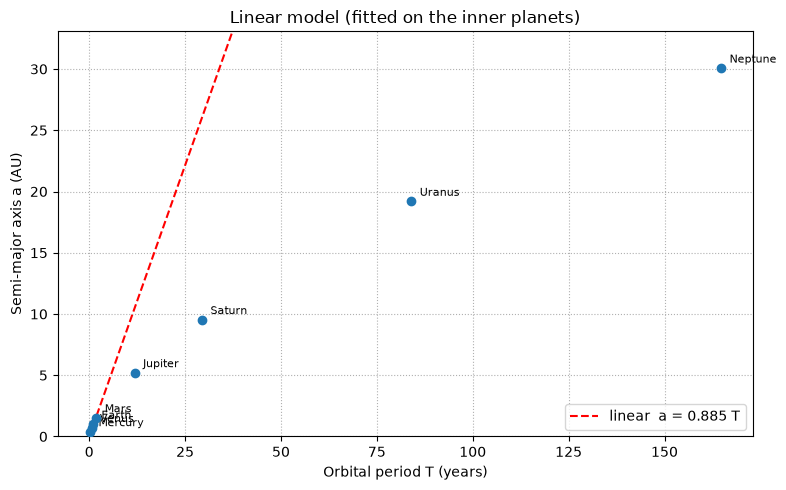

In [5]:
ax = plot_data()
T_line = np.linspace(0, planets["T_years"].max(), 200)
ax.plot(T_line, c * T_line, "r--", label=f"linear  a = {c:.3f} T")
ax.set_ylim(0, planets["a_au"].max() * 1.1)
ax.legend()
plt.title("Linear model (fitted on the inner planets)")
plt.tight_layout()
plt.show()

## 2. Trying different models on all eight planets

Now we fit three different model *shapes* to **all eight** planets and compare their loss:

| model | formula | free parameters |
|---|---|---|
| linear | $a = c\,T$ | 1 |
| quadratic | $a = \alpha T^2 + \beta T + \gamma$ | 3 |
| power law | $a = C\,T^{\,p}$ | 2 |

The power law is neither a straight line nor a polynomial. The trick to fit it: taking the
logarithm of $a = C\,T^{p}$ gives
$$ \log a = \log C + p \,\log T, $$
which **is** a straight line in $\log T$ and $\log a$. So we fit a straight line in log–log space.

In [6]:
T = planets["T_years"].values
a = planets["a_au"].values

# linear through the origin
c_all = np.sum(T * a) / np.sum(T ** 2)
a_linear = c_all * T

# quadratic: a = alpha T^2 + beta T + gamma
quad = np.polyfit(T, a, 2)
a_quad = np.polyval(quad, T)

# power law: fit a straight line in log-log space
p, logC = np.polyfit(np.log(T), np.log(a), 1)
C = np.exp(logC)
a_power = C * T ** p

print(f"linear    : a = {c_all:.4f} T")
print(f"            MSE = {mse(a, a_linear):.4f}")
print()
print(f"quadratic : a = {quad[0]:.4e} T^2 + {quad[1]:.4f} T + {quad[2]:.4f}")
print(f"            MSE = {mse(a, a_quad):.4f}")
print()
print(f"power law : a = {C:.4f} * T^{p:.4f}      <-- look at the exponent!")
print(f"            MSE = {mse(a, a_power):.6f}")

linear    : a = 0.1963 T
            MSE = 4.6641

quadratic : a = -6.2672e-04 T^2 + 0.2788 T + 0.9728
            MSE = 0.3920

power law : a = 1.0000 * T^0.6667      <-- look at the exponent!
            MSE = 0.000001


Notice the exponent the power-law fit found. Let's plot all three models on top of the data,
on ordinary axes and on log–log axes.

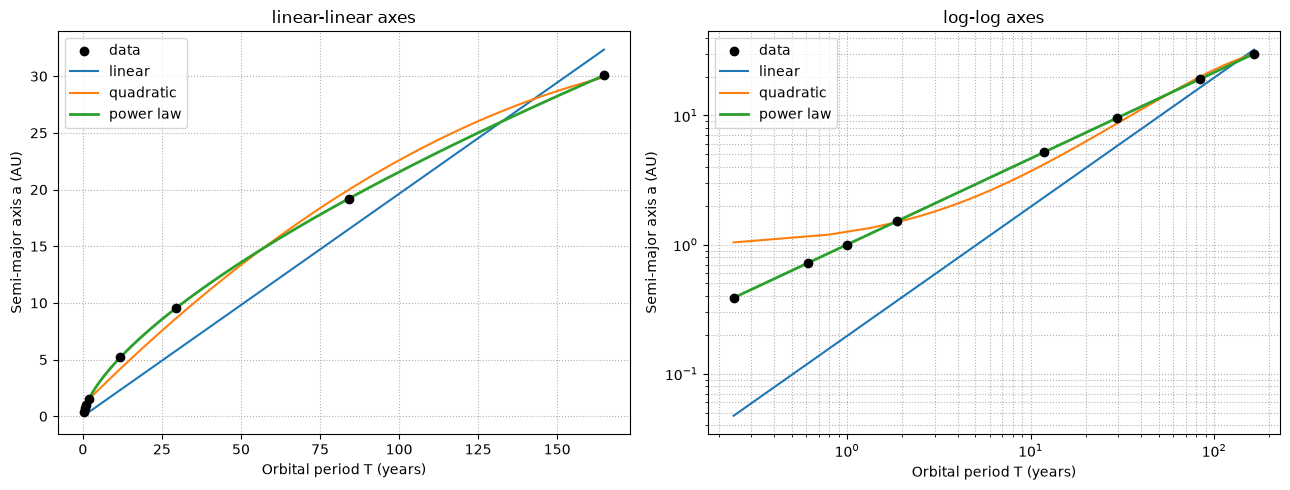

In [7]:
T_line = np.linspace(planets["T_years"].min(), planets["T_years"].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, scale in zip(axes, ["linear", "log"]):
    ax.scatter(T, a, color="black", zorder=5, label="data")
    ax.plot(T_line, c_all * T_line, label="linear")
    ax.plot(T_line, np.polyval(quad, T_line), label="quadratic")
    ax.plot(T_line, C * T_line ** p, label="power law", linewidth=2)
    ax.set_xscale(scale)
    ax.set_yscale(scale)
    ax.set_xlabel("Orbital period T (years)")
    ax.set_ylabel("Semi-major axis a (AU)")
    ax.set_title(f"{scale}-{scale} axes")
    ax.grid(True, which="both", linestyle=":")
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Which model is best?

In [8]:
results = pd.DataFrame({
    "model":        ["linear (a = cT)", "quadratic", "power law (a = C T^p)"],
    "MSE":          [mse(a, a_linear), mse(a, a_quad), mse(a, a_power)],
    "# parameters": [1, 3, 2],
})
results

,model,MSE,# parameters
0,linear (a = cT),4.664071e+00,1
1,quadratic,3.920363e-01,3
2,power law (a = C T^p),8.683012e-07,2


### What we see

- The **linear** model has a large loss: a straight line cannot follow the curve.
- The **quadratic** model is better, but still not perfect.
- The **power law** fits almost perfectly — its loss is essentially zero.

And look at the exponent the power-law fit found:

$$ p \approx 0.667 \approx \tfrac{2}{3}, \qquad C \approx 1. $$

So the planets follow $a = T^{2/3}$ remarkably well. **Keep this exponent in mind** — in the
section *Discover Kepler's Law* we will see what it means.

### The lesson

We did not know in advance what shape the relation would have. By trying several models and
comparing their loss, we let the data tell us which one fits. **You have to try different
models** — and a model with the *right shape* can fit far better than a more complicated one
with more parameters: here the power law (2 parameters) beats the quadratic (3 parameters).